# Adaptive Financial Transformer

## Objective

The previous notebook introduced a fixed Price-Aware Attention mechanism that biased attention using price differences.

Although it improved trading metrics, it significantly reduced regression performance.

This notebook introduces an Adaptive Financial Attention mechanism.

Instead of using a single handcrafted price bias, the attention layer combines multiple financial signals:

- Price Difference
- Recent Returns
- Volatility

Each bias has a learnable importance coefficient, allowing the model to determine which market information is most useful during training.

This architecture forms the final proposed model of the project.

In [1]:
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from pipeline.metrics import evaluate_trading_metrics

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [3]:
X_train = np.load("pipeline/X_train.npy")
X_val = np.load("pipeline/X_val.npy")
X_test = np.load("pipeline/X_test.npy")

y_train = np.load("pipeline/y_train.npy")
y_val = np.load("pipeline/y_val.npy")
y_test = np.load("pipeline/y_test.npy")

In [4]:
X_train = torch.tensor(X_train,dtype=torch.float32).to(DEVICE)
X_val = torch.tensor(X_val,dtype=torch.float32).to(DEVICE)
X_test = torch.tensor(X_test,dtype=torch.float32).to(DEVICE)

y_train = torch.tensor(y_train,dtype=torch.float32).to(DEVICE)
y_val = torch.tensor(y_val,dtype=torch.float32).to(DEVICE)
y_test = torch.tensor(y_test,dtype=torch.float32).to(DEVICE)

In [5]:
SEQ_LENGTH = X_train.shape[1]
INPUT_DIM = X_train.shape[2]
D_MODEL = 128
NUM_HEADS = 8
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.1
EPOCHS = 15
LEARNING_RATE = 1e-3
PATIENCE = 5

In [8]:
baseline_results = pd.read_csv("experiments/baseline_results.csv")
trading_results = pd.read_csv("experiments/trading_results.csv")
experiment_log = pd.read_csv("experiments/experiment_log.csv")

## Positional Encoding

Transformers are permutation invariant, so positional information must be injected into the input embeddings.

The sinusoidal positional encoding proposed in the original Transformer paper is reused.

In [33]:
class PositionalEncoding(nn.Module):
    def __init__(self,d_model,max_len=5000):
        super().__init__()
        pe=torch.zeros(max_len,d_model)
        position=torch.arange(max_len).unsqueeze(1)
        div_term=torch.exp(torch.arange(0,d_model,2)*(-math.log(10000.0)/d_model))
        pe[:,0::2]=torch.sin(position*div_term)
        pe[:,1::2]=torch.cos(position*div_term)
        self.register_buffer("pe",pe.unsqueeze(0))

    def forward(self,x):
        return x+self.pe[:,:x.size(1)]

In [34]:
pe=PositionalEncoding(D_MODEL)
print(pe.pe.shape)

torch.Size([1, 5000, 128])


## Adaptive Financial Attention

The previous notebook introduced a fixed price-aware attention mechanism.

Here we extend the attention mechanism by incorporating multiple financial relationships between timesteps.

Three similarity matrices are computed:

- Price Difference
- Return Difference
- Volatility Difference

Instead of manually choosing their importance, the model learns three coefficients during training.

This allows the attention mechanism to adapt automatically to different market conditions.

In [35]:
class AdaptiveFinancialAttention(nn.Module):
    def __init__(self,d_k,num_heads,d_model):
        super().__init__()
        self.scale=math.sqrt(d_k)
        self.num_heads=num_heads
        self.gate=nn.Sequential(
            nn.Linear(d_model,64),
            nn.GELU(),
            nn.Linear(64,3*num_heads)
        )

    def forward(self,Q,K,V,prices,features):

        scores=torch.matmul(Q,K.transpose(-2,-1))/self.scale
        pooled=features.mean(dim=1)
        coeff=self.gate(pooled)
        coeff=coeff.view(-1,3,self.num_heads,1,1)
        alpha=torch.sigmoid(coeff[:,0])
        beta=torch.sigmoid(coeff[:,1])
        gamma=torch.sigmoid(coeff[:,2])
        returns=prices[:,1:]-prices[:,:-1]
        returns=F.pad(returns,(1,0))
        volatility=torch.abs(returns)
        price_diff=torch.abs(prices.unsqueeze(-1)-prices.unsqueeze(-2))
        return_diff=torch.abs(returns.unsqueeze(-1)-returns.unsqueeze(-2))
        vol_diff=torch.abs(volatility.unsqueeze(-1)-volatility.unsqueeze(-2))
        price_diff=price_diff/(price_diff.mean()+1e-8)
        return_diff=return_diff/(return_diff.mean()+1e-8)
        vol_diff=vol_diff/(vol_diff.mean()+1e-8)
        scores=scores-alpha*price_diff.unsqueeze(1)
        scores=scores-beta*return_diff.unsqueeze(1)
        scores=scores-gamma*vol_diff.unsqueeze(1)
        weights=F.softmax(scores,dim=-1)
        output=torch.matmul(weights,V)
        return output,weights

In [36]:
attention=AdaptiveFinancialAttention(
    d_k=64,
    num_heads=8,
    d_model=128
)
Q=torch.randn(2,8,60,64)
K=torch.randn(2,8,60,64)
V=torch.randn(2,8,60,64)
prices=torch.randn(2,60)
features=torch.randn(2,60,128)
out,weights=attention(Q,K,V,prices,features)
print(out.shape)
print(weights.shape)

torch.Size([2, 8, 60, 64])
torch.Size([2, 8, 60, 60])


## Multi-Head Attention

The Adaptive Financial Attention module is applied independently to each attention head.

Each head learns contextual relationships using both feature similarity and financial market biases.

In [37]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_model,num_heads):
        super().__init__()

        assert d_model%num_heads==0

        self.num_heads=num_heads
        self.head_dim=d_model//num_heads

        self.q_proj=nn.Linear(d_model,d_model)
        self.k_proj=nn.Linear(d_model,d_model)
        self.v_proj=nn.Linear(d_model,d_model)

        self.attention=AdaptiveFinancialAttention(self.head_dim,self.num_heads, d_model)

        self.out_proj=nn.Linear(d_model,d_model)

    def forward(self,x,prices):
        B,L,_=x.shape

        Q=self.q_proj(x).view(B,L,self.num_heads,self.head_dim).transpose(1,2)
        K=self.k_proj(x).view(B,L,self.num_heads,self.head_dim).transpose(1,2)
        V=self.v_proj(x).view(B,L,self.num_heads,self.head_dim).transpose(1,2)

        out,weights=self.attention(Q,K,V,prices,x)

        out=out.transpose(1,2).contiguous().view(B,L,-1)

        out=self.out_proj(out)

        return out,weights

In [38]:
mha=MultiHeadAttention(D_MODEL,NUM_HEADS)

dummy=torch.randn(4,SEQ_LENGTH,D_MODEL)
prices=torch.randn(4,SEQ_LENGTH)

out,weights=mha(dummy,prices)

print(out.shape)
print(weights.shape)

torch.Size([4, 60, 128])
torch.Size([4, 8, 60, 60])


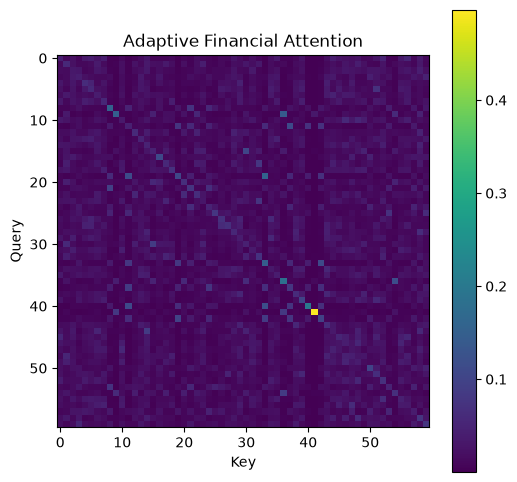

In [39]:
plt.figure(figsize=(6,6))
plt.imshow(weights[0,0].detach().cpu().numpy(),cmap="viridis")
plt.colorbar()
plt.title("Adaptive Financial Attention")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()

## Adaptive Encoder Layer

Each encoder layer consists of:

- Adaptive Multi-Head Attention
- Residual Connection
- Layer Normalization
- Feed Forward Network
- Residual Connection
- Layer Normalization

In [40]:
class FeedForward(nn.Module):
    def __init__(self,d_model,ff_dim,dropout=0.1):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(d_model,ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim,d_model)
        )

    def forward(self,x):
        return self.net(x)

In [41]:
class EncoderBlock(nn.Module):
    def __init__(self,d_model,num_heads,ff_dim,dropout=0.1):
        super().__init__()
        self.attention=MultiHeadAttention(d_model,num_heads)
        self.norm1=nn.LayerNorm(d_model)
        self.norm2=nn.LayerNorm(d_model)
        self.ffn=FeedForward(d_model,ff_dim,dropout)
        self.dropout=nn.Dropout(dropout)
    def forward(self,x,prices):
        attn_out,weights=self.attention(x,prices)
        x=self.norm1(x+self.dropout(attn_out))
        ff_out=self.ffn(x)
        x=self.norm2(x+self.dropout(ff_out))
        return x,weights

In [42]:
encoder=EncoderBlock(D_MODEL,NUM_HEADS,FF_DIM,DROPOUT)
dummy=torch.randn(8,SEQ_LENGTH,D_MODEL)
prices=torch.randn(8,SEQ_LENGTH)
out,weights=encoder(dummy,prices)
print(out.shape)
print(weights.shape)

torch.Size([8, 60, 128])
torch.Size([8, 8, 60, 60])


## Adaptive Financial Transformer

The complete model consists of:

- Input Projection
- Positional Encoding
- Adaptive Encoder Stack
- Global Average Pooling
- Regression Head

Unlike previous notebooks, every encoder layer receives financial context through the adaptive attention mechanism.

In [43]:
class AdaptiveFinancialTransformer(nn.Module):
    def __init__(self,input_dim,d_model,num_heads,ff_dim,num_layers,dropout=0.1):
        super().__init__()

        self.embedding=nn.Linear(input_dim,d_model)
        self.position=PositionalEncoding(d_model)
        self.dropout=nn.Dropout(dropout)

        self.layers=nn.ModuleList([
            EncoderBlock(d_model,num_heads,ff_dim,dropout)
            for _ in range(num_layers)
        ])

        self.regressor=nn.Linear(d_model,1)

    def forward(self,x):
        prices=x[:,:,0]

        x=self.embedding(x)
        x=self.position(x)
        x=self.dropout(x)

        attention_maps=[]

        for layer in self.layers:
            x,weights=layer(x,prices)
            attention_maps.append(weights)

        x=x.mean(dim=1)

        pred=self.regressor(x).squeeze(-1)

        return pred,attention_maps

In [44]:
model=AdaptiveFinancialTransformer(
    INPUT_DIM,
    D_MODEL,
    NUM_HEADS,
    FF_DIM,
    NUM_LAYERS,
    DROPOUT
).to(DEVICE)

model

AdaptiveFinancialTransformer(
  (embedding): Linear(in_features=95, out_features=128, bias=True)
  (position): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x EncoderBlock(
      (attention): MultiHeadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (attention): AdaptiveFinancialAttention(
          (gate): Sequential(
            (0): Linear(in_features=128, out_features=64, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=64, out_features=24, bias=True)
          )
        )
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForw

In [45]:
dummy=torch.randn(16,SEQ_LENGTH,INPUT_DIM).to(DEVICE)

pred,attention=model(dummy)

print(pred.shape)
print(len(attention))
print(attention[0].shape)

torch.Size([16])
2
torch.Size([16, 8, 60, 60])


In [46]:
total=sum(p.numel() for p in model.parameters())
trainable=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters : {total:,}")
print(f"Trainable Parameters : {trainable:,}")

Total Parameters : 297,009
Trainable Parameters : 297,009


## Loss Function and Optimizer

The model is trained using AdamW with gradient clipping and mixed precision training.

In [47]:
criterion=nn.MSELoss()

optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

scaler=torch.amp.GradScaler("cuda")

In [48]:
best_loss=float("inf")
best_epoch=0
patience_counter=0

train_losses=[]
val_losses=[]

start_time=time.time()

## Training Loop

In [49]:
for epoch in range(EPOCHS):

    model.train()
    optimizer.zero_grad()

    with torch.amp.autocast("cuda"):
        pred,_=model(X_train)
        train_loss=criterion(pred,y_train)

    scaler.scale(train_loss).backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

    scaler.step(optimizer)
    scaler.update()

    model.eval()

    with torch.no_grad():
        with torch.amp.autocast("cuda"):
            val_pred,_=model(X_val)
            val_loss=criterion(val_pred,y_val)

    scheduler.step(val_loss)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss<best_loss:
        best_loss=val_loss
        best_epoch=epoch+1
        patience_counter=0
        torch.save(model.state_dict(),"models/adaptive_financial_transformer.pth")
    else:
        patience_counter+=1

    if patience_counter>=PATIENCE:
        print("Early stopping")
        break

Epoch 01/15 | Train 0.021599 | Val 0.156422
Epoch 02/15 | Train 0.224326 | Val 0.156422
Epoch 03/15 | Train 0.225378 | Val 0.119779
Epoch 04/15 | Train 0.061500 | Val 0.003639
Epoch 05/15 | Train 0.040352 | Val 0.084016
Epoch 06/15 | Train 0.060409 | Val 0.127851
Epoch 07/15 | Train 0.033398 | Val 0.027703
Epoch 08/15 | Train 0.021171 | Val 0.010028
Epoch 09/15 | Train 0.020618 | Val 0.029976
Early stopping


In [50]:
train_time=time.time()-start_time
print(f"Training Time : {train_time:.2f} sec")
print(f"Best Epoch : {best_epoch}")
print(f"Best Validation Loss : {best_loss:.6f}")

Training Time : 52.83 sec
Best Epoch : 4
Best Validation Loss : 0.003639


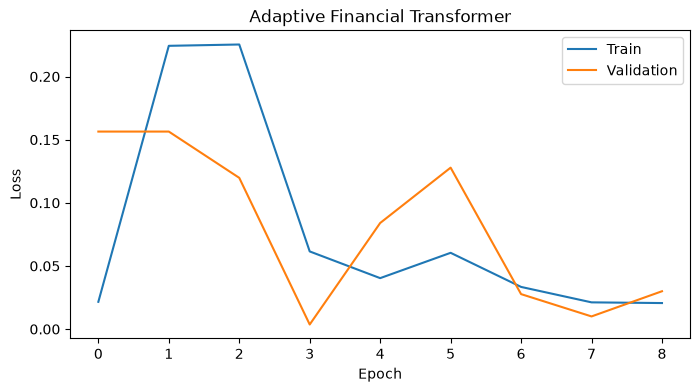

In [51]:
plt.figure(figsize=(8,4))
plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adaptive Financial Transformer")
plt.legend()
plt.show()

In [52]:
model.load_state_dict(torch.load("models/adaptive_financial_transformer.pth"))
model.eval()

AdaptiveFinancialTransformer(
  (embedding): Linear(in_features=95, out_features=128, bias=True)
  (position): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x EncoderBlock(
      (attention): MultiHeadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (attention): AdaptiveFinancialAttention(
          (gate): Sequential(
            (0): Linear(in_features=128, out_features=64, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=64, out_features=24, bias=True)
          )
        )
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForw

In [53]:
with torch.no_grad():
    pred,attention=model(X_test)

pred=pred.cpu().numpy()
true=y_test.cpu().numpy()

In [54]:
mae=mean_absolute_error(true,pred)
rmse=np.sqrt(mean_squared_error(true,pred))
r2=r2_score(true,pred)

print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²  : {r2:.6f}")

MAE : 0.131486
RMSE: 0.152851
R²  : -12.141038


In [57]:
metrics=evaluate_trading_metrics(true,pred)

for k,v in metrics.items():
    print(f"{k}: {v}")

Directional Accuracy: 0.5644699140401146
Hit Rate: 0.5644699140401146
Sharpe: 1.7527435211050182
Strategy Return: 2.6947522163391113
Max Drawdown: -0.7979198098182678


In [55]:
baseline=pd.read_csv("experiments/baseline_results.csv")

baseline.loc[len(baseline)]=[
    "Adaptive Financial Transformer",
    mae,
    rmse,
    r2
]

baseline.to_csv("experiments/baseline_results.csv",index=False)

baseline.sort_values("MAE")

,Model,MAE,RMSE,R2
6,Custom Transformer,0.030962,0.043111,-0.045353
5,PyTorch Transformer,0.032234,0.043543,-0.066416
1,Random Forest,0.033050,0.045135,-0.145847
4,XGBoost,0.034423,0.045011,-0.139553
3,GRU,0.034453,0.047614,-0.275127
2,LSTM,0.040036,0.052256,-0.535912
8,Adaptive Financial Transformer,0.131486,0.152851,-12.141038
0,Linear Regression,0.188742,0.248706,-33.790931
7,Price Aware Transformer,0.280036,0.284159,-44.416771


In [58]:
trading=pd.read_csv("experiments/trading_results.csv")

trading.loc[len(trading)]=[
    "Adaptive Financial Transformer",
    metrics["Directional Accuracy"],
    metrics["Hit Rate"],
    metrics["Sharpe"],
    metrics["Strategy Return"],
    metrics["Max Drawdown"]
]

trading.to_csv("experiments/trading_results.csv",index=False)

trading.sort_values("Sharpe",ascending=False)

,Model,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown
4,GRU,0.578797,0.578797,2.789059,8.535793,-0.703745
7,Price-Aware Transformer,0.564470,0.564470,1.752744,2.694752,-0.797920
8,Adaptive Financial Transformer,0.564470,0.564470,1.752744,2.694752,-0.797920
1,Random Forest,0.515759,0.515759,0.334000,0.001970,-0.675468
6,Custom Transformer,0.521490,0.521490,0.177760,-0.139390,-0.601280
2,XGBoost,0.489971,0.489971,-0.132552,-0.350803,-0.741019
3,LSTM,0.478510,0.478510,-0.142696,-0.357364,-0.782726
0,Linear Regression,0.467049,0.467049,-0.398144,-0.494425,-0.694398
5,PyTorch Transformer,0.441261,0.441261,-0.799614,-0.651581,-0.850522


In [66]:
experiment_log=pd.read_csv("experiments/experiment_log.csv")

experiment_log.loc[len(experiment_log)]={
    "Experiment":"Adaptive Financial Transformer",
    "Model":"Adaptive Financial Transformer",
    "Parameters":sum(p.numel() for p in model.parameters()),
    "Train Time (s)":round(train_time,2),
    "Epochs":best_epoch,
    "MAE":mae,
    "RMSE":rmse,
    "R2":r2,
    "Directional Accuracy":metrics["Directional Accuracy"],
    "Hit Rate":metrics["Hit Rate"],
    "Sharpe":metrics["Sharpe"],
    "Strategy Return":metrics["Strategy Return"],
    "Max Drawdown":metrics["Max Drawdown"],
    "Notes":"Dynamic gated adaptive financial attention"
}

experiment_log.to_csv("experiments/experiment_log.csv",index=False)

experiment_log.tail()

,Experiment,Model,Parameters,Train Time (s),Epochs,MAE,RMSE,R2,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown,Notes
14,Custom Transformer,Custom Transformer,277377.0,2.023901,5.0,0.280036,0.284159,-44.416771,0.56447,0.56447,1.752744,2.694752,-0.79792,Price-Aware Attention
15,Adaptive Financial Transformer,Adaptive Financial Transformer,297009.0,52.830000,4.0,0.131486,0.152851,-12.141038,0.56447,0.56447,1.752744,2.694752,-0.79792,Dynamic gated adaptive financial attention
16,Adaptive Financial Transformer,Adaptive Financial Transformer,297009.0,52.830000,4.0,0.131486,0.152851,-12.141038,0.56447,0.56447,1.752744,2.694752,-0.79792,Dynamic gated adaptive financial attention
17,Adaptive Financial Transformer,Adaptive Financial Transformer,297009.0,52.830000,4.0,0.131486,0.152851,-12.141038,0.56447,0.56447,1.752744,2.694752,-0.79792,Dynamic gated adaptive financial attention
18,Adaptive Financial Transformer,Adaptive Financial Transformer,297009.0,52.830000,4.0,0.131486,0.152851,-12.141038,0.56447,0.56447,1.752744,2.694752,-0.79792,Dynamic gated adaptive financial attention


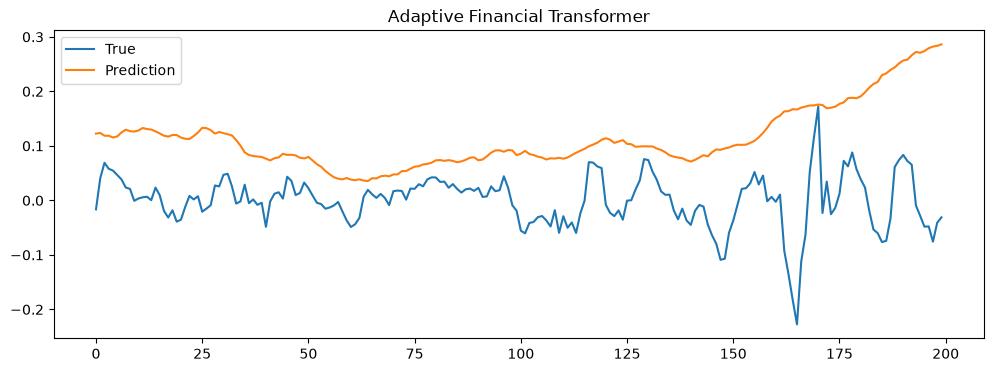

In [60]:
plt.figure(figsize=(12,4))
plt.plot(true[:200],label="True")
plt.plot(pred[:200],label="Prediction")
plt.title("Adaptive Financial Transformer")
plt.legend()
plt.show()

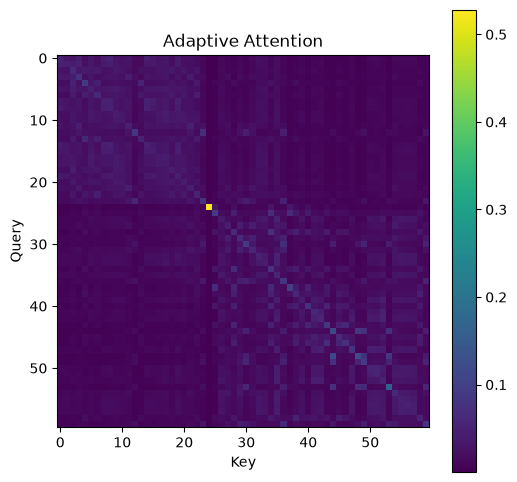

In [61]:
sample=X_test[:1]

with torch.no_grad():
    _,attention=model(sample)

attn=attention[-1][0,0].cpu().numpy()

plt.figure(figsize=(6,6))
plt.imshow(attn,cmap="viridis")
plt.colorbar()
plt.title("Adaptive Attention")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()

In [62]:
layer=model.layers[0]

gate_input=model.embedding(X_test[:32])
gate_input=gate_input.mean(dim=1)

with torch.no_grad():
    coeff=layer.attention.attention.gate(gate_input)

coeff=coeff.view(-1,3,NUM_HEADS)

alpha=torch.sigmoid(coeff[:,0]).mean(0).cpu().numpy()
beta=torch.sigmoid(coeff[:,1]).mean(0).cpu().numpy()
gamma=torch.sigmoid(coeff[:,2]).mean(0).cpu().numpy()

gate_df=pd.DataFrame({
    "Head":range(1,NUM_HEADS+1),
    "Price":alpha,
    "Return":beta,
    "Volatility":gamma
})

gate_df

,Head,Price,Return,Volatility
0,1,0.471960,0.620998,0.446238
1,2,0.479333,0.533424,0.485357
2,3,0.493271,0.536147,0.505341
3,4,0.482493,0.417220,0.544217
4,5,0.560069,0.545593,0.459916
5,6,0.586868,0.485095,0.405333
6,7,0.450141,0.537439,0.548384
7,8,0.450998,0.491516,0.472561


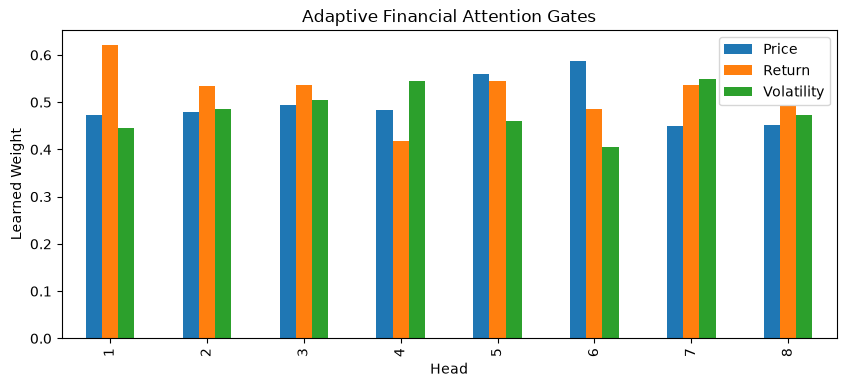

In [63]:
gate_df.set_index("Head").plot(kind="bar",figsize=(10,4))
plt.ylabel("Learned Weight")
plt.title("Adaptive Financial Attention Gates")
plt.show()